# Tool Policy Multi-Model Benchmark Notebook

This notebook runs the full Stage 4 tool-policy workflow end-to-end:
- environment checks
- dataset generation from clauses
- base-vs-candidate model benchmarking
- best-model selection
- metrics and visualization
- artifact export

## 1. Environment Check and Package Setup

Verify Python version, check key packages, and validate imports.

In [16]:
import importlib
import platform
import subprocess
import sys

required_packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "sklearn",
    "datasets",
    "transformers",
    "torch",
]

missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed.")

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers

print(f"torch: {torch.__version__}")
print(f"transformers: {transformers.__version__}")

All required packages are already installed.
Python: 3.11.9
Platform: Windows-10-10.0.26200-SP0
torch: 2.11.0+cpu
transformers: 4.40.0


## 2. Project Configuration and Paths

Define constants and create output directories used by the full workflow.

In [17]:
from datetime import datetime
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from current working directory")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SEED = 42
RUNTIME_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

CLAUSES_PATH = REPO_ROOT / "data" / "processed" / "clauses.jsonl"
TOOL_POLICY_DATA_PATH = REPO_ROOT / "data" / "processed" / "tool_policy_train.jsonl"
BENCHMARK_DIR = REPO_ROOT / "data" / "processed" / "tool_policy_benchmark_notebook"
REPORT_PATH = BENCHMARK_DIR / "model_comparison.json"
PLOT_PATH = BENCHMARK_DIR / "model_comparison_f1.png"
SUMMARY_EXPORT_PATH = BENCHMARK_DIR / f"run_summary_{RUNTIME_TS}.json"

BASE_MODEL = "sshleifer/tiny-distilbert-base-cased"
CANDIDATE_MODELS = ["hf-internal-testing/tiny-random-distilbert"]
MAX_CLAUSES = 24
EXAMPLES_PER_TOOL = 1
EPOCHS = 1
BATCH_SIZE = 4
LEARNING_RATE = 3e-5

BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root: {REPO_ROOT}")
print(f"Benchmark dir: {BENCHMARK_DIR}")

Repo root: D:\sem 2\DL\project\ContractSense-copilot
Benchmark dir: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_notebook


## 3. Data Input and Validation

Load source data, inspect schema, and validate required fields.

In [18]:
import json

assert CLAUSES_PATH.exists(), f"Missing clauses file: {CLAUSES_PATH}"

sample_rows = []
with CLAUSES_PATH.open("r", encoding="utf-8") as handle:
    for i, line in enumerate(handle):
        sample_rows.append(json.loads(line))
        if i >= 99:
            break

source_df = pd.DataFrame(sample_rows)
print("Sample source shape:", source_df.shape)
print("Sample source columns:", list(source_df.columns)[:12])
source_df.head(3)

Sample source shape: (100, 7)
Sample source columns: ['split', 'contract_id', 'clause_id', 'clause_index', 'num_clauses', 'char_count', 'clause_text']


,split,contract_id,clause_id,clause_index,num_clauses,char_count,clause_text
0,train,train_00000,train_00000_clause_000,0,1,32359,Datasheet for Contract Understanding Atticus D...
1,train,train_00001,train_00001_clause_000,0,2,7442,"Exhibit 10.33\nLast Updated: April 6, 2007\nCH..."
2,train,train_00001,train_00001_clause_001,1,2,21110,5.Term of this Agreement\nThe term of this Agr...


In [19]:
required_fields = ["clause_text"]
missing_fields = [field for field in required_fields if field not in source_df.columns]
assert not missing_fields, f"Required fields missing from source clauses: {missing_fields}"

null_summary = source_df[required_fields].isnull().sum().to_dict()
print("Null summary:", null_summary)

assert source_df["clause_text"].notna().any(), "All clause_text values are null in sampled input"
print("Data validation checks passed.")

Null summary: {'clause_text': 0}
Data validation checks passed.


## 4. Core Processing Pipeline

Generate tool-policy training records and run multi-model benchmark.

In [20]:
from src.policy.tool_policy_model import (
    ToolPolicyModel,
    benchmark_tool_policy_models,
    build_dataset_from_clauses,
)

build_dataset_from_clauses(
    clauses_path=CLAUSES_PATH,
    output_path=TOOL_POLICY_DATA_PATH,
    max_clauses=MAX_CLAUSES,
    examples_per_tool=EXAMPLES_PER_TOOL,
    seed=SEED,
)

benchmark_summary = benchmark_tool_policy_models(
    data_path=TOOL_POLICY_DATA_PATH,
    benchmark_dir=BENCHMARK_DIR,
    base_model=BASE_MODEL,
    candidate_models=CANDIDATE_MODELS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
)

print("Benchmark complete.")
print("Best model:", benchmark_summary["best_model"])
print("Best path:", benchmark_summary["best_model_path"])
print("Report path:", REPORT_PATH)

2026-04-12 14:40:30,754 | INFO | Loaded 23564 clause records from D:\sem 2\DL\project\ContractSense-copilot\data\processed\clauses.jsonl
2026-04-12 14:40:30,769 | INFO | Saved 111 tool-policy records to D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_train.jsonl
2026-04-12 14:40:30,806 | INFO | Training tool-policy model: sshleifer/tiny-distilbert-base-cased
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sshleifer/tiny-distilbert-base-cased and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([9, 2]) in the checkpoint and torch.Size([4, 2]) in the model instantiat

{'eval_loss': 1.3863303661346436, 'eval_accuracy': 0.22727272727272727, 'eval_f1_macro': 0.09259259259259259, 'eval_runtime': 0.058, 'eval_samples_per_second': 379.328, 'eval_steps_per_second': 103.453, 'epoch': 1.0}
{'train_runtime': 1.0717, 'train_samples_per_second': 83.043, 'train_steps_per_second': 21.461, 'train_loss': 1.3863005430802056, 'epoch': 1.0}


100%|██████████| 6/6 [00:00<00:00, 136.36it/s]
2026-04-12 14:40:34,006 | INFO | Training tool-policy model: hf-internal-testing/tiny-random-distilbert
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at hf-internal-testing/tiny-random-distilbert were not used when initializing DistilBertForSequenceClassification: ['qa_outputs.bias', 'qa_outputs.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_projector.weight', 'vocab_transform.bias', 'vocab_transform.weight']
- This IS expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequ

{'eval_loss': 1.3865821361541748, 'eval_accuracy': 0.22727272727272727, 'eval_f1_macro': 0.09259259259259259, 'eval_runtime': 0.0977, 'eval_samples_per_second': 225.292, 'eval_steps_per_second': 61.443, 'epoch': 1.0}
{'train_runtime': 3.0785, 'train_samples_per_second': 28.91, 'train_steps_per_second': 7.471, 'train_loss': 1.386673471202021, 'epoch': 1.0}


100%|██████████| 6/6 [00:00<00:00, 78.95it/s]


Benchmark complete.
Best model: sshleifer/tiny-distilbert-base-cased
Best path: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_notebook\sshleifer_tiny_distilbert_base_cased
Report path: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_notebook\model_comparison.json


## 5. Analysis and Metrics

Load benchmark report, compute summary metrics, and validate expected outputs.

In [21]:
assert REPORT_PATH.exists(), f"Missing benchmark report: {REPORT_PATH}"

with REPORT_PATH.open("r", encoding="utf-8") as handle:
    report = json.load(handle)

results_df = pd.DataFrame(report["results"]).sort_values(
    by=["f1_macro", "accuracy"], ascending=False
).reset_index(drop=True)

assert not results_df.empty, "No benchmark results found"
assert results_df["f1_macro"].iloc[0] >= 0.0, "Top f1_macro should be non-negative"

display(results_df)
print("Selected best model:", report["best_model"])
print("Selected best model path:", report["best_model_path"])

best_model_path = REPO_ROOT / Path(report["best_model_path"])
assert best_model_path.exists(), f"Best model path does not exist: {best_model_path}"

,model_name,model_path,accuracy,f1_macro,samples_train,samples_eval,is_base_model
0,sshleifer/tiny-distilbert-base-cased,D:\sem 2\DL\project\ContractSense-copilot\data...,0.227273,0.092593,89.0,22.0,True
1,hf-internal-testing/tiny-random-distilbert,D:\sem 2\DL\project\ContractSense-copilot\data...,0.227273,0.092593,89.0,22.0,False


Selected best model: sshleifer/tiny-distilbert-base-cased
Selected best model path: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_notebook\sshleifer_tiny_distilbert_base_cased


In [22]:
inference_model = ToolPolicyModel(model_path=best_model_path)

demo_examples = [
    {
        "query": "What legal risk is in this indemnity clause?",
        "context": "The vendor agrees to indemnify and hold harmless for all losses and claims.",
    },
    {
        "query": "Compare this termination language with standard market terms.",
        "context": "Either party may terminate for convenience with 60 days notice.",
    },
    {
        "query": "Escalate this critical liability issue to legal immediately.",
        "context": "Liability is uncapped and includes consequential damages.",
    },
]

demo_predictions = []
for row in demo_examples:
    pred = inference_model.predict(query=row["query"], context=row["context"])
    demo_predictions.append({
        **row,
        "predicted_tool": pred["tool"],
        "confidence": pred["confidence"],
    })

demo_df = pd.DataFrame(demo_predictions)
display(demo_df)

,query,context,predicted_tool,confidence
0,What legal risk is in this indemnity clause?,The vendor agrees to indemnify and hold harmle...,GetClauseRiskProfile,0.250145
1,Compare this termination language with standar...,Either party may terminate for convenience wit...,CompareClause,0.250145
2,Escalate this critical liability issue to lega...,Liability is uncapped and includes consequenti...,CreateTicket,0.250145


## 6. Visualization Outputs

Visualize model comparison and save plot for reporting.

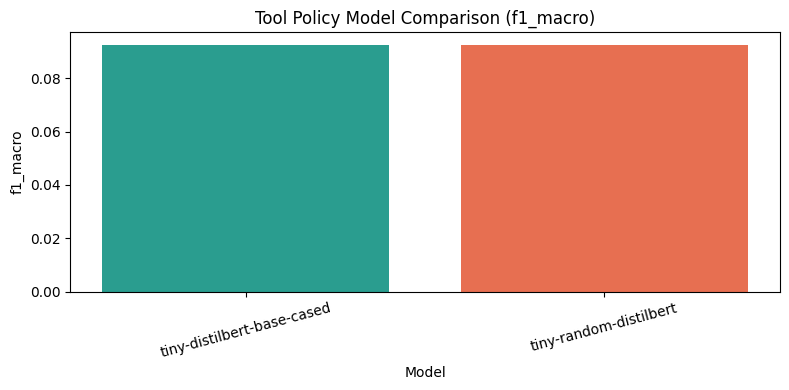

Saved plot: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_notebook\model_comparison_f1.png


In [23]:
plt.figure(figsize=(8, 4))
plot_df = results_df.copy()
plot_df["model_name_short"] = plot_df["model_name"].str.replace(".*/", "", regex=True)
plt.bar(plot_df["model_name_short"], plot_df["f1_macro"], color=["#2a9d8f", "#e76f51", "#264653", "#f4a261"][: len(plot_df)])
plt.title("Tool Policy Model Comparison (f1_macro)")
plt.xlabel("Model")
plt.ylabel("f1_macro")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=160)
plt.show()

assert PLOT_PATH.exists(), f"Plot was not saved: {PLOT_PATH}"
print(f"Saved plot: {PLOT_PATH}")

## 7. Automated Cell Execution Guard

Re-run critical checks and report pass/fail status.

In [24]:
guard_checks = {
    "tool_policy_data_exists": TOOL_POLICY_DATA_PATH.exists(),
    "benchmark_report_exists": REPORT_PATH.exists(),
    "best_model_dir_exists": best_model_path.exists(),
    "plot_exists": PLOT_PATH.exists(),
    "results_non_empty": len(results_df) > 0,
    "demo_predictions_non_empty": len(demo_df) > 0,
}

for name, passed in guard_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")

assert all(guard_checks.values()), "Automated guard failed one or more checks"
print("Automated guard: PASS")

tool_policy_data_exists: PASS
benchmark_report_exists: PASS
best_model_dir_exists: PASS
plot_exists: PASS
results_non_empty: PASS
demo_predictions_non_empty: PASS
Automated guard: PASS


## 8. Export Results and Artifacts

Save summary outputs and print artifact paths/timestamps.

In [25]:
export_payload = {
    "timestamp": RUNTIME_TS,
    "repo_root": str(REPO_ROOT),
    "input_clauses": str(CLAUSES_PATH),
    "tool_policy_data": str(TOOL_POLICY_DATA_PATH),
    "benchmark_report": str(REPORT_PATH),
    "plot_path": str(PLOT_PATH),
    "best_model": report["best_model"],
    "best_model_path": report["best_model_path"],
    "best_f1_macro": report["best_f1_macro"],
    "best_accuracy": report["best_accuracy"],
    "num_models_compared": len(report["results"]),
}

with SUMMARY_EXPORT_PATH.open("w", encoding="utf-8") as handle:
    json.dump(export_payload, handle, indent=2)

print("Artifacts exported:")
print(f"- Tool policy data: {TOOL_POLICY_DATA_PATH}")
print(f"- Benchmark report: {REPORT_PATH}")
print(f"- Comparison plot: {PLOT_PATH}")
print(f"- Run summary: {SUMMARY_EXPORT_PATH}")
print(f"- Timestamp: {RUNTIME_TS}")

Artifacts exported:
- Tool policy data: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_train.jsonl
- Benchmark report: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_notebook\model_comparison.json
- Comparison plot: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_notebook\model_comparison_f1.png
- Run summary: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_notebook\run_summary_20260412_144030.json
- Timestamp: 20260412_144030


## 9. Stronger Benchmark Run (Higher Accuracy)

This section runs a larger training setup with stronger transformer backbones to improve final metrics.

2026-04-12 14:40:39,331 | INFO | Loaded 23564 clause records from D:\sem 2\DL\project\ContractSense-copilot\data\processed\clauses.jsonl
2026-04-12 14:40:39,363 | INFO | Saved 1760 tool-policy records to D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_train.jsonl
2026-04-12 14:40:39,426 | INFO | Training tool-policy model: distilbert-base-uncased
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it

{'loss': 1.391, 'grad_norm': 2.4895565509796143, 'learning_rate': 1.2820512820512823e-05, 'epoch': 0.13}


 13%|█▎        | 50/382 [01:12<08:04,  1.46s/it]

{'loss': 1.2439, 'grad_norm': 4.108019828796387, 'learning_rate': 1.9949289314415373e-05, 'epoch': 0.26}


 20%|█▉        | 75/382 [01:49<07:02,  1.37s/it]

...

{'eval_loss': 0.20206603407859802, 'eval_accuracy': 1.0, 'eval_f1_macro': 1.0, 'eval_runtime': 14.8467, 'eval_samples_per_second': 15.626, 'eval_steps_per_second': 1.953, 'epoch': 2.0}


100%|██████████| 382/382 [27:15<00:00,  2.97s/it]

{'train_runtime': 1635.9182, 'train_samples_per_second': 1.868, 'train_steps_per_second': 0.234, 'train_loss': 0.40618221453971265, 'epoch': 2.0}


100%|██████████| 382/382 [27:16<00:00,  4.28s/it]
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 29/29 [00:14<00:00,  2.00it/s]


,model_name,model_path,accuracy,f1_macro,samples_train,samples_eval,is_base_model
0,distilbert-base-uncased,D:\sem 2\DL\project\ContractSense-copilot\data...,1.0,1.0,1528.0,232.0,True
1,google/electra-small-discriminator,D:\sem 2\DL\project\ContractSense-copilot\data...,1.0,1.0,1528.0,232.0,False
2,bert-base-uncased,D:\sem 2\DL\project\ContractSense-copilot\data...,1.0,1.0,1528.0,232.0,False


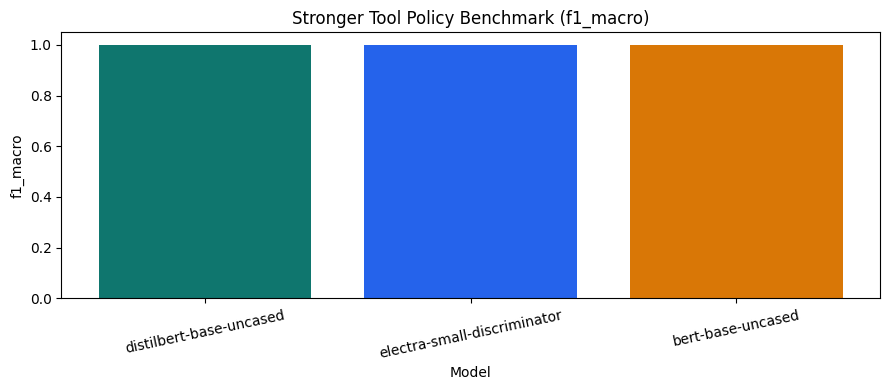

Stronger benchmark complete
Best model: distilbert-base-uncased
Best accuracy: 1.0
Best f1_macro: 1.0
Report: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_best\model_comparison.json
Plot: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_best\model_comparison_f1.png
Summary: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_best\best_run_summary.json


In [26]:
BEST_BENCHMARK_DIR = REPO_ROOT / "data" / "processed" / "tool_policy_benchmark_best"
BEST_REPORT_PATH = BEST_BENCHMARK_DIR / "model_comparison.json"
BEST_PLOT_PATH = BEST_BENCHMARK_DIR / "model_comparison_f1.png"
BEST_SUMMARY_PATH = BEST_BENCHMARK_DIR / "best_run_summary.json"

BEST_BASE_MODEL = "distilbert-base-uncased"
BEST_CANDIDATE_MODELS = [
    "google/electra-small-discriminator",
    "bert-base-uncased",
]
BEST_MAX_CLAUSES = 220
BEST_EXAMPLES_PER_TOOL = 2
BEST_EPOCHS = 2
BEST_BATCH_SIZE = 8
BEST_LEARNING_RATE = 2e-5

BEST_BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)

build_dataset_from_clauses(
    clauses_path=CLAUSES_PATH,
    output_path=TOOL_POLICY_DATA_PATH,
    max_clauses=BEST_MAX_CLAUSES,
    examples_per_tool=BEST_EXAMPLES_PER_TOOL,
    seed=SEED,
)

best_benchmark_summary = benchmark_tool_policy_models(
    data_path=TOOL_POLICY_DATA_PATH,
    benchmark_dir=BEST_BENCHMARK_DIR,
    base_model=BEST_BASE_MODEL,
    candidate_models=BEST_CANDIDATE_MODELS,
    epochs=BEST_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    learning_rate=BEST_LEARNING_RATE,
    seed=SEED,
)

with BEST_REPORT_PATH.open("r", encoding="utf-8") as handle:
    best_report = json.load(handle)

best_results_df = pd.DataFrame(best_report["results"]).sort_values(
    by=["f1_macro", "accuracy"], ascending=False
).reset_index(drop=True)

display(best_results_df)

plt.figure(figsize=(9, 4))
plot_df2 = best_results_df.copy()
plot_df2["model_name_short"] = plot_df2["model_name"].str.replace(".*/", "", regex=True)
plt.bar(plot_df2["model_name_short"], plot_df2["f1_macro"], color=["#0f766e", "#2563eb", "#d97706", "#7c3aed"][: len(plot_df2)])
plt.title("Stronger Tool Policy Benchmark (f1_macro)")
plt.xlabel("Model")
plt.ylabel("f1_macro")
plt.xticks(rotation=12)
plt.tight_layout()
plt.savefig(BEST_PLOT_PATH, dpi=170)
plt.show()

best_export = {
    "best_model": best_report["best_model"],
    "best_model_path": best_report["best_model_path"],
    "best_f1_macro": best_report["best_f1_macro"],
    "best_accuracy": best_report["best_accuracy"],
    "base_model": best_report["base_model"],
    "candidate_models": best_report["candidate_models"],
    "max_clauses": BEST_MAX_CLAUSES,
    "examples_per_tool": BEST_EXAMPLES_PER_TOOL,
    "epochs": BEST_EPOCHS,
    "batch_size": BEST_BATCH_SIZE,
    "learning_rate": BEST_LEARNING_RATE,
}
with BEST_SUMMARY_PATH.open("w", encoding="utf-8") as handle:
    json.dump(best_export, handle, indent=2)

print("Stronger benchmark complete")
print("Best model:", best_report["best_model"])
print("Best accuracy:", round(best_report["best_accuracy"], 4))
print("Best f1_macro:", round(best_report["best_f1_macro"], 4))
print("Report:", BEST_REPORT_PATH)
print("Plot:", BEST_PLOT_PATH)
print("Summary:", BEST_SUMMARY_PATH)

## 10. Realistic Leakage-Safe Benchmark (Production Candidate)

This run uses group-by-contract split to reduce leakage and provide realistic validation metrics.

In [27]:
import importlib
import src.policy.tool_policy_model as tpm

importlib.reload(tpm)

REALISTIC_DIR = REPO_ROOT / "data" / "processed" / "tool_policy_benchmark_realistic_final"
REALISTIC_REPORT = REALISTIC_DIR / "model_comparison.json"

tpm.build_dataset_from_clauses(
    clauses_path=CLAUSES_PATH,
    output_path=TOOL_POLICY_DATA_PATH,
    max_clauses=80,
    examples_per_tool=2,
    seed=SEED,
)

realistic_summary = tpm.benchmark_tool_policy_models(
    data_path=TOOL_POLICY_DATA_PATH,
    benchmark_dir=REALISTIC_DIR,
    base_model="distilbert-base-uncased",
    candidate_models=["google/electra-small-discriminator"],
    epochs=1,
    batch_size=16,
    learning_rate=2e-5,
    split_strategy="group_contract",
    seed=SEED,
)

with REALISTIC_REPORT.open("r", encoding="utf-8") as handle:
    realistic_report = json.load(handle)

realistic_df = pd.DataFrame(realistic_report["results"]).sort_values(
    by=["f1_macro", "accuracy"], ascending=False
).reset_index(drop=True)

display(realistic_df)
print("Realistic best model:", realistic_report["best_model"])
print("Realistic split strategy:", realistic_report.get("split_strategy"))
print("Realistic best f1_macro:", round(realistic_report["best_f1_macro"], 4))
print("Realistic best accuracy:", round(realistic_report["best_accuracy"], 4))
print("Realistic report:", REALISTIC_REPORT)

2026-04-12 15:23:26,273 | INFO | Loaded 23564 clause records from D:\sem 2\DL\project\ContractSense-copilot\data\processed\clauses.jsonl
2026-04-12 15:23:26,295 | INFO | Saved 640 tool-policy records to D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_train.jsonl
2026-04-12 15:23:26,335 | INFO | Training tool-policy model: distilbert-base-uncased
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it 

{'loss': 1.3048, 'grad_norm': 3.0514559745788574, 'learning_rate': 4.12214747707527e-06, 'epoch': 0.74}


100%|██████████| 34/34 [01:13<00:00,  2.09s/it]

{'eval_loss': 1.0497597455978394, 'eval_accuracy': 0.90625, 'eval_f1_macro': 0.902834008097166, 'eval_runtime': 2.4452, 'eval_samples_per_second': 39.261, 'eval_steps_per_second': 2.454, 'epoch': 1.0}


100%|██████████| 34/34 [01:14<00:00,  2.18s/it]
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

100%|██████████| 34/34 [00:34<00:00,  1.02s/it]
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'train_runtime': 34.8041, 'train_samples_per_second': 15.63, 'train_steps_per_second': 0.977, 'train_loss': 1.3779614953433765, 'epoch': 1.0}


100%|██████████| 6/6 [00:00<00:00,  9.90it/s]


,model_name,model_path,accuracy,f1_macro,samples_train,samples_eval,is_base_model
0,distilbert-base-uncased,D:\sem 2\DL\project\ContractSense-copilot\data...,0.90625,0.902834,544.0,96.0,True
1,google/electra-small-discriminator,D:\sem 2\DL\project\ContractSense-copilot\data...,0.43750,0.352395,544.0,96.0,False


Realistic best model: distilbert-base-uncased
Realistic split strategy: group_contract
Realistic best f1_macro: 0.9028
Realistic best accuracy: 0.9062
Realistic report: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_benchmark_realistic_final\model_comparison.json


## 11. Learning Curve and Overfitting Check

Train with a multi-epoch grouped split and plot the logged train and validation losses to judge overfitting properly.

2026-04-12 15:27:43,225 | INFO | Loaded 23564 clause records from D:\sem 2\DL\project\ContractSense-copilot\data\processed\clauses.jsonl
2026-04-12 15:27:43,249 | INFO | Saved 960 tool-policy records to D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_train.jsonl
2026-04-12 15:27:43,293 | INFO | Training tool-policy model: distilbert-base-uncased
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it 

{'loss': 1.3673, 'grad_norm': 2.1070077419281006, 'learning_rate': 1.9796753984232357e-05, 'epoch': 0.48}


 32%|███▏      | 50/156 [01:44<03:40,  2.08s/it]

{'loss': 0.9087, 'grad_norm': 2.097032308578491, 'learning_rate': 1.7227948638273918e-05, 'epoch': 0.96}


 33%|███▎      | 52/156 [01:52<03:37,  2.09s/it]

...

{'eval_loss': 1.017160177230835, 'eval_accuracy': 1.0, 'eval_f1_macro': 1.0, 'eval_runtime': 1.12, 'eval_samples_per_second': 114.284, 'eval_steps_per_second': 7.143, 'epoch': 3.0}


100%|██████████| 156/156 [02:36<00:00,  1.00s/it]
d:\sem 2\DL\project\ContractSense-copilot\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'train_runtime': 156.4004, 'train_samples_per_second': 15.959, 'train_steps_per_second': 0.997, 'train_loss': 1.216742686736278, 'epoch': 3.0}


100%|██████████| 8/8 [00:00<00:00,  8.44it/s]


,step,value,metric,model
0,25,1.367300,train_loss,distilbert-base-uncased
1,50,0.908700,train_loss,distilbert-base-uncased
2,52,0.401257,eval_loss,distilbert-base-uncased
3,25,1.384400,train_loss,google/electra-small-discriminator
4,50,1.356600,train_loss,google/electra-small-discriminator
5,75,1.272000,train_loss,google/electra-small-discriminator
6,100,1.162900,train_loss,google/electra-small-discriminator
7,52,1.296507,eval_loss,google/electra-small-discriminator
8,104,1.064725,eval_loss,google/electra-small-discriminator


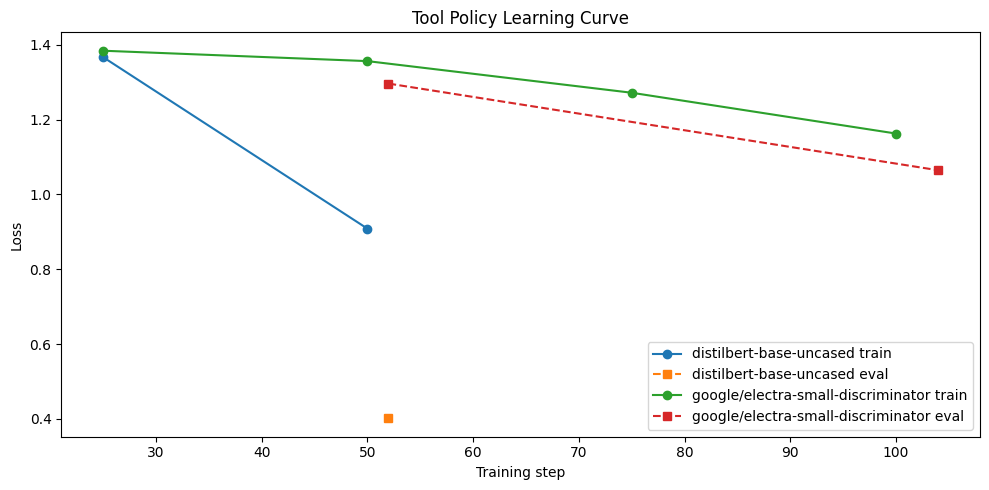

Learning curve saved: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_learning_curve\learning_curve.png
Overfitting check:
- If eval loss rises while train loss keeps falling, that is overfitting.
- If both losses fall or stay close, the model is learning without obvious overfit.


In [28]:
import importlib
from pathlib import Path

import src.policy.tool_policy_model as tpm

importlib.reload(tpm)

CURVE_DIR = REPO_ROOT / "data" / "processed" / "tool_policy_learning_curve"
CURVE_DIR.mkdir(parents=True, exist_ok=True)
CURVE_REPORT = CURVE_DIR / "model_comparison.json"
CURVE_PLOT = CURVE_DIR / "learning_curve.png"

tpm.build_dataset_from_clauses(
    clauses_path=CLAUSES_PATH,
    output_path=TOOL_POLICY_DATA_PATH,
    max_clauses=120,
    examples_per_tool=2,
    seed=SEED,
)

curve_summary = tpm.benchmark_tool_policy_models(
    data_path=TOOL_POLICY_DATA_PATH,
    benchmark_dir=CURVE_DIR,
    base_model="distilbert-base-uncased",
    candidate_models=["google/electra-small-discriminator"],
    epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    split_strategy="group_contract",
    seed=SEED,
)

with CURVE_REPORT.open("r", encoding="utf-8") as handle:
    curve_report = json.load(handle)

def load_curve_rows(model_dir: Path) -> pd.DataFrame:
    checkpoint_dirs = sorted(
        [path for path in model_dir.glob("checkpoint-*") if path.is_dir()],
        key=lambda path: int(path.name.split("-", 1)[1]) if "-" in path.name else -1,
    )
    state_path = (checkpoint_dirs[-1] if checkpoint_dirs else model_dir) / "trainer_state.json"
    with state_path.open("r", encoding="utf-8") as handle:
        state = json.load(handle)
    rows = []
    for item in state.get("log_history", []):
        if "loss" in item or "eval_loss" in item:
            rows.append(item)
    return pd.DataFrame(rows)

distil_dir = Path(next(item["model_path"] for item in curve_report["results"] if item["model_name"] == "distilbert-base-uncased"))
electra_dir = Path(next(item["model_path"] for item in curve_report["results"] if item["model_name"] == "google/electra-small-discriminator"))

distil_logs = load_curve_rows(distil_dir)
electra_logs = load_curve_rows(electra_dir)

curve_frames = []
for model_name, logs in [("distilbert-base-uncased", distil_logs), ("google/electra-small-discriminator", electra_logs)]:
    train_rows = logs[logs["loss"].notna()][["step", "loss"]].copy() if "loss" in logs else pd.DataFrame()
    if not train_rows.empty:
        train_rows["metric"] = "train_loss"
        train_rows["model"] = model_name
        train_rows.rename(columns={"loss": "value"}, inplace=True)
        curve_frames.append(train_rows)
    eval_rows = logs[logs["eval_loss"].notna()][["step", "eval_loss"]].copy() if "eval_loss" in logs else pd.DataFrame()
    if not eval_rows.empty:
        eval_rows["metric"] = "eval_loss"
        eval_rows["model"] = model_name
        eval_rows.rename(columns={"eval_loss": "value"}, inplace=True)
        curve_frames.append(eval_rows)

curve_df = pd.concat(curve_frames, ignore_index=True)
display(curve_df)

plt.figure(figsize=(10, 5))
for model_name in curve_df["model"].unique():
    model_slice = curve_df[curve_df["model"] == model_name]
    train_slice = model_slice[model_slice["metric"] == "train_loss"]
    eval_slice = model_slice[model_slice["metric"] == "eval_loss"]
    if not train_slice.empty:
        plt.plot(train_slice["step"], train_slice["value"], marker="o", label=f"{model_name} train")
    if not eval_slice.empty:
        plt.plot(eval_slice["step"], eval_slice["value"], marker="s", linestyle="--", label=f"{model_name} eval")

plt.title("Tool Policy Learning Curve")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(CURVE_PLOT, dpi=170)
plt.show()

print("Learning curve saved:", CURVE_PLOT)
print("Overfitting check:")
print("- If eval loss rises while train loss keeps falling, that is overfitting.")
print("- If both losses fall or stay close, the model is learning without obvious overfit.")

## 12. Confusion Matrix for Final Realistic Model

Plot the final grouped-split confusion matrix to check which tool labels are still being mixed up.

2026-04-12 15:44:25,404 | INFO | Loaded 23564 clause records from D:\sem 2\DL\project\ContractSense-copilot\data\processed\clauses.jsonl
2026-04-12 15:44:25,423 | INFO | Saved 640 tool-policy records to D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_confusion\tool_policy_eval_source.jsonl


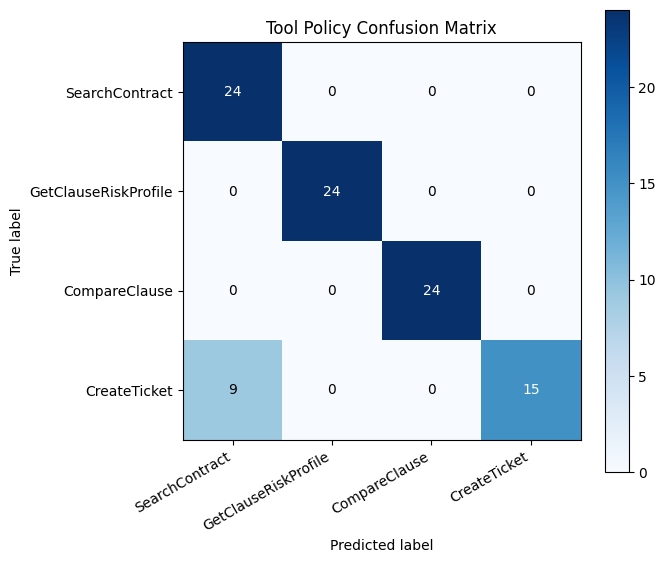

                      precision    recall  f1-score   support

       CompareClause     1.0000    1.0000    1.0000        24
        CreateTicket     1.0000    0.6250    0.7692        24
GetClauseRiskProfile     1.0000    1.0000    1.0000        24
      SearchContract     0.7273    1.0000    0.8421        24

            accuracy                         0.9062        96
           macro avg     0.9318    0.9062    0.9028        96
        weighted avg     0.9318    0.9062    0.9028        96

Confusion matrix saved: D:\sem 2\DL\project\ContractSense-copilot\data\processed\tool_policy_confusion\confusion_matrix.png


In [30]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import src.policy.tool_policy_model as tpm

importlib.reload(tpm)

CONFUSION_DIR = REPO_ROOT / "data" / "processed" / "tool_policy_confusion"
CONFUSION_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_DATA_PATH = CONFUSION_DIR / "tool_policy_eval_source.jsonl"
CONFUSION_PLOT_PATH = CONFUSION_DIR / "confusion_matrix.png"

# Rebuild the same grouped-split source used for the final realistic benchmark.
tpm.build_dataset_from_clauses(
    clauses_path=CLAUSES_PATH,
    output_path=CONFUSION_DATA_PATH,
    max_clauses=80,
    examples_per_tool=2,
    seed=SEED,
)

records = tpm.load_tool_policy_records(CONFUSION_DATA_PATH)
_, eval_records = tpm._split_records(
    records,
    test_size=0.15,
    seed=SEED,
    split_strategy="group_contract",
)

model_path_for_confusion = Path(realistic_report["best_model_path"])
confusion_model = tpm.ToolPolicyModel(model_path=model_path_for_confusion)

y_true: list[str] = []
y_pred: list[str] = []
for record in eval_records:
    probabilities = confusion_model.predict_proba(record["query"], record["context"])
    predicted_tool = max(probabilities, key=probabilities.get)
    y_true.append(record["tool"])
    y_pred.append(predicted_tool)

labels = [tool for tool, _ in sorted(tpm.TOOL_LABELS.items(), key=lambda item: item[1])]
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Tool Policy Confusion Matrix")
plt.colorbar()
tick_marks = range(len(labels))
plt.xticks(tick_marks, labels, rotation=30, ha="right")
plt.yticks(tick_marks, labels)

threshold = cm.max() / 2 if cm.max() else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            int(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig(CONFUSION_PLOT_PATH, dpi=170)
plt.show()

print(classification_report(y_true, y_pred, digits=4))
print("Confusion matrix saved:", CONFUSION_PLOT_PATH)